In [1]:
import sys
PATH = "your/path/to/PRIVET/repo"
sys.path.append(f"{PATH}/PRIVET")

import time

from src.misc_utils import *
from src.data_utils import *
from src.nn_utils import *
from src.stats_utils import *
from src.plot_utils import *
from src.privet import *

In [2]:
ngpu=1
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)

cuda:0


In [3]:
###############
###LOAD DATA###
###############
PATH = "your/path/to/data"
dat=np.load(f"{PATH}/65k_all_labels.npy",allow_pickle=True)

np.random.seed(42)
np.random.shuffle(dat)
dat = dat[:3*(dat.shape[0]//3)] #5006 is not divisible by 3, 5004 is
train, test, synth = dat[:dat.shape[0]//3,3:], dat[dat.shape[0]//3:2*(dat.shape[0]//3),3:], dat[2*(dat.shape[0]//3):,3:]
train, test, synth = train.astype(int), test.astype(int), synth.astype(int)

train_torch = torch.tensor(train, dtype = torch.uint8)
test_torch = torch.tensor(test, dtype = torch.uint8)
synth_torch = torch.tensor(synth, dtype = torch.uint8)


In [4]:
train.shape, test.shape, synth.shape

((1668, 65535), (1668, 65535), (1668, 65535))

In [5]:
Xtrain_torch = torch.vstack([train_torch,test_torch])

N = Xtrain_torch.shape[0]

In [6]:
# the EVT fit will be done on the fusion of train and test (also called val in paper)
# the goal is to retrieve train among concat(train,test)

############################
## COMPUTE 1-NN distances ##
############################
#Train-Train
dist_NN_tr_tr,  dist_NN_tr_tr_idx = gpu_nearest_neighbors(Xtrain_torch, k=1,distance='hamming',chunk_size=128,device=device.type,verbose=False)
p_tr_tr_NN_dist, p_tr_tr_NN_idx = sorting(dist_NN_tr_tr, dist_NN_tr_tr_idx)
p_tr_tr_NN_dist, p_tr_tr_NN_idx = np.array(p_tr_tr_NN_dist), np.array(p_tr_tr_NN_idx)

In [7]:
#Needed to construct the pseudo-synthetic data
#Synth-Train
dist_NN_syn_tr_INIT, dist_NN_syn_tr_INIT_idx = gpu_nearest_neighbors(synth_torch, train_torch, k=1,distance='hamming',chunk_size=128,device=device.type,verbose=False)
p_syn_tr_NN_dist_INIT, p_syn_tr_NN_idx_INIT = sorting(dist_NN_syn_tr_INIT, dist_NN_syn_tr_INIT_idx)
p_syn_tr_NN_dist_INIT, p_syn_tr_NN_idx_INIT = np.array(p_syn_tr_NN_dist_INIT), np.array(p_syn_tr_NN_idx_INIT)
indices_s_tr_INIT = dist_NN_syn_tr_INIT_idx.squeeze(1)

In [8]:
##############################################
## EVT FIT CDF on (Train+Test)-(Train+Test) ##
##############################################

partition_start = 0.01
partition_end = 0.2

start = int(np.ceil(partition_start*N)) #int(0.01*N) # if N is small start = 0 --> problem with log
end = int(partition_end*N)

# Fit parameters (adjust start/end indices to avoid extremes)
intercept, alpha, std_err_intercept, std_err_alpha, sigma_Y_pred = fit_nearest_neighbor_cdf_weibull(p_tr_tr_NN_dist.reshape(-1,), start_idx=start, end_idx=end)

print(f"Estimated intercept = {intercept:.2f} ± {std_err_intercept:.2f}")
print(f"Estimated alpha = {alpha:.2f} ± {std_err_alpha:.2f}")

Estimated intercept = -134.31 ± 1.58
Estimated alpha = 14.30 ± 0.17


In [9]:
#for the renormalisation
_lambda=synth.shape[0]/Xtrain_torch.shape[0]
_lambda

0.5

In [ ]:
leakage_configs = [(0.3,0.1),(0.3,0.2), (0.3,0.3)]

store_scores_4plot = []

for i, (f_fake,f_copy) in enumerate(leakage_configs):
    print(f_fake,f_copy)
    fake = generate_fake_synth(train, synth, indices_s_tr_INIT, f_fake=f_fake, f_copy=f_copy)
    
    flist = np.zeros((Xtrain_torch.shape[0],))
    flist[:1668] = 1
    flist=flist.astype(bool)
    
    store, p_tr = PRIVET_inverse(
        Xtrain_torch, torch.tensor(fake),
        intercept, alpha,
        renormalization=_lambda**(-1/alpha),
        distance='hamming',
        device=device.type, 
        groundtruth=flist
    )
    
    scores = np.log10(store[:,0])

    store_scores_4plot.append(scores)


0.3 0.1


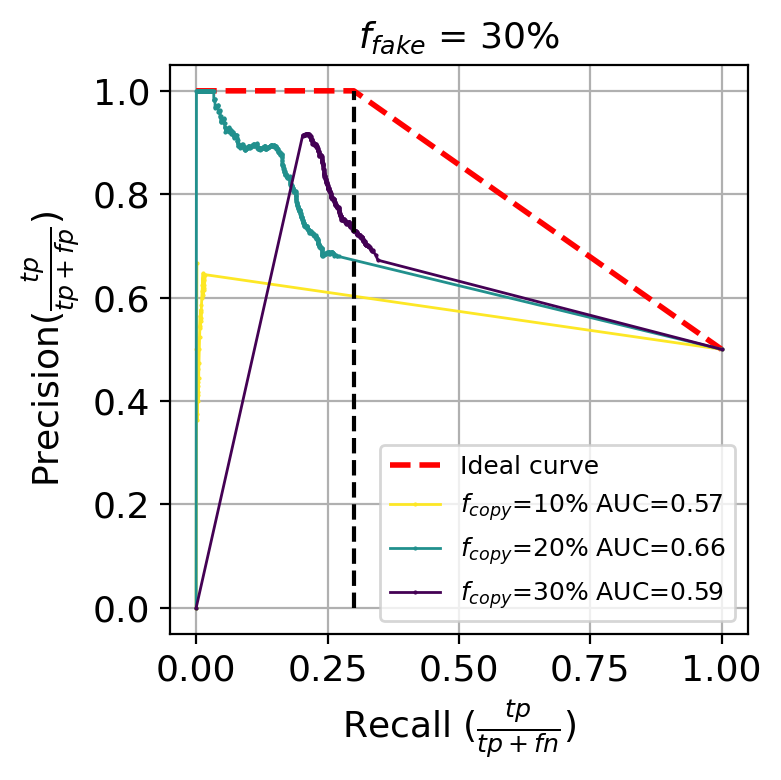

In [18]:
leakage_configs = [(0.3,0.1), (0.3,0.2), (0.3,0.3)]  # Only keep f_fake=0.3 configurations

cmap = plt.cm.viridis_r
colors = cmap(np.linspace(0, 1, 3))  # 3 colors for the 3 f_copy values

FONTSIZE=13

plt.rcParams.update({
    'axes.labelsize': FONTSIZE,
    'axes.titlesize': FONTSIZE,
    'xtick.labelsize': FONTSIZE,
    'ytick.labelsize': FONTSIZE
})

# Create single plot
fig, ax = plt.subplots(figsize=(4, 4), dpi=200, facecolor="white")

f_fake = 0.3  # Hardcoded value

# Plot ideal curve
x_ideal = np.concatenate([np.linspace(0, f_fake, 50), np.linspace(f_fake, 1, 50)])
y_ideal = np.concatenate([np.ones(50), np.linspace(1, 0.5, 50)])
ax.plot(x_ideal, y_ideal, '--', color='red', label='Ideal curve', linewidth=2)

# Plot actual curves
for i, (_, f_copy) in enumerate(leakage_configs):
    scores = store_scores_4plot[i]  # Assuming indices 0-2 now correspond to the 0.3 configs
    
    unique_vals = np.sort(np.unique(scores))
    midpoints = (unique_vals[:-1] + unique_vals[1:]) / 2
    thresholds = np.concatenate(([unique_vals[0] - 1], midpoints, [unique_vals[-1] + 1]))
    
    x_fpr, y_tpr, auc_roc, y_precision, x_recall, auc_pr, threshold_lst, tp_lst, fp_lst, tn_lst, fn_lst = roc(flist, scores, thresholds)
    
    ax.plot(x_recall, y_precision, 
            label=r"$f_{copy}$"+f"={int(f_copy*100)}%"+f" AUC={np.round(auc_pr,2)}",
            marker=".", markersize=1, linewidth=1, color=colors[i])

ax.set_xlim([-0.05, 1.05])
ax.set_ylim([-0.05, 1.05])
ax.set_title(r"$f_{fake}$"+f" = {int(f_fake*100)}%")
ax.set_ylabel(r"Precision($\frac{tp}{tp + fp}$)")
ax.set_xlabel(r"Recall ($\frac{tp}{tp + fn}$)")
ax.vlines(f_fake, 0, 1, color="black", linestyle="dashed")
ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
ax.grid(True)

# Add legend
leg = ax.legend(prop={'size': 9}, loc='lower right')
for lh in leg.legend_handles:
    lh.set_alpha(1)

fig.tight_layout()
plt.show()